# BrainScanAI — Analyse non supervisée et clustering

## Objectifs

Cette étape vise à :

- standardiser les embeddings extraits par ResNet-50 ;
- réduire leur dimension avec PCA ;
- produire des visualisations PCA et t-SNE ;
- comparer plusieurs algorithmes de clustering ;
- rechercher deux groupes correspondant potentiellement aux classes
  `normal` et `cancer` ;
- évaluer les regroupements sur les 100 images fortement annotées avec
  l'Adjusted Rand Index ;
- préparer une labellisation faible des 1 406 images non annotées.

## Séparation des données

Les labels experts ne sont jamais transmis aux algorithmes de clustering.

Ils sont utilisés uniquement après le clustering pour :

- calculer l'ARI ;
- interpréter la composition des clusters ;
- associer ultérieurement un sens médical prudent aux identifiants de clusters.

Le futur fichier de labels faibles sera conservé séparément du fichier
contenant les labels experts.

## 1. Imports et configuration

In [42]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [43]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Imports réussis.")

Imports réussis.


## 2. Chargement des embeddings

Les matrices `layer3` et `avgpool` générées à l'étape précédente sont
rechargées avec leurs métadonnées.

Les fichiers se trouvent dans `data/processed` et restent exclus de Git.

In [44]:
def trouver_racine_projet(repertoire_depart: Path) -> Path:
    """
    Recherche la racine du projet contenant pyproject.toml.
    """

    for candidat in (
        repertoire_depart,
        *repertoire_depart.parents,
    ):
        if (candidat / "pyproject.toml").exists():
            return candidat

    raise FileNotFoundError(
        "Impossible de localiser la racine du projet."
    )


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = trouver_racine_projet(CURRENT_DIR)

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features"
    / "resnet50_imagenet1k_v2"
)

LAYER3_PATH = FEATURES_DIR / "embeddings_layer3.npy"
AVGPOOL_PATH = FEATURES_DIR / "embeddings_avgpool.npy"
METADATA_PATH = FEATURES_DIR / "metadata.csv"

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clustering"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Features : {FEATURES_DIR}")
print(f"Sorties clustering : {OUTPUT_DIR}")
print()

print(f"Layer3 présent : {LAYER3_PATH.exists()}")
print(f"Avgpool présent : {AVGPOOL_PATH.exists()}")
print(f"Métadonnées présentes : {METADATA_PATH.exists()}")

Features : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/features/resnet50_imagenet1k_v2
Sorties clustering : /Users/vincentdesmouceaux/dev/BrainScanAI/data/processed/clustering

Layer3 présent : True
Avgpool présent : True
Métadonnées présentes : True


In [45]:
X_layer3 = np.load(
    LAYER3_PATH,
).astype(np.float32)

X_avgpool = np.load(
    AVGPOOL_PATH,
).astype(np.float32)

df_metadata = pd.read_csv(
    METADATA_PATH,
)

print(f"Layer3 : {X_layer3.shape}")
print(f"Avgpool : {X_avgpool.shape}")
print(f"Métadonnées : {df_metadata.shape}")

Layer3 : (1506, 1024)
Avgpool : (1506, 2048)
Métadonnées : (1506, 10)


In [46]:
assert X_layer3.shape == (1506, 1024)
assert X_avgpool.shape == (1506, 2048)
assert len(df_metadata) == 1506

assert np.isfinite(X_layer3).all()
assert np.isfinite(X_avgpool).all()

print("Embeddings et métadonnées validés.")

Embeddings et métadonnées validés.


7. Séparer fortement et non labellisé

## 3. Séparation stricte des données

Deux index distincts sont créés :

- `strong_mask` pour les 100 images disposant d'un label expert ;
- `unlabeled_mask` pour les 1 406 images sans label.

Aucun label faible ne sera ajouté dans le tableau des labels experts.

In [47]:
strong_mask = (
    df_metadata["label"]
    .notna()
    .to_numpy()
)

unlabeled_mask = (
    df_metadata["label"]
    .isna()
    .to_numpy()
)

df_strong_reference = (
    df_metadata.loc[strong_mask]
    .reset_index(drop=True)
    .copy()
)

df_unlabeled_reference = (
    df_metadata.loc[unlabeled_mask]
    .reset_index(drop=True)
    .copy()
)

y_strong = (
    df_strong_reference["label_id"]
    .astype(int)
    .to_numpy()
)

print(
    "Images fortement labellisées :",
    len(df_strong_reference),
)

print(
    "Images non labellisées :",
    len(df_unlabeled_reference),
)

display(
    df_strong_reference["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="nombre_images")
)

Images fortement labellisées : 100
Images non labellisées : 1406


,label,nombre_images
0,cancer,50
1,normal,50


In [48]:
assert len(df_strong_reference) == 100
assert len(df_unlabeled_reference) == 1406
assert not df_strong_reference["label"].isna().any()
assert df_unlabeled_reference["label"].isna().all()

print("Séparation des données : OK")

Séparation des données : OK


8. Standardisation et PCA

La PCA est une réduction linéaire qui projette les données dans un espace de dimension inférieure. Comme PCA centre les données mais ne les standardise pas feature par feature, nous appliquons explicitement StandardScaler avant elle.

## 4. Standardisation et réduction de dimension

Pour chaque représentation :

1. les features sont standardisées ;
2. une PCA conserve au moins 95 % de la variance ;
3. une PCA à deux dimensions est créée pour la visualisation ;
4. une projection t-SNE est calculée à partir d'au plus 50 composantes PCA.

Les labels experts ne sont utilisés dans aucune de ces opérations.

In [49]:
def preparer_representation(
    X: np.ndarray,
    nom: str,
) -> dict:
    """
    Standardise une matrice puis construit les projections PCA et t-SNE.
    """

    scaler = StandardScaler()

    X_standardise = scaler.fit_transform(
        X
    ).astype(np.float32)

    pca_clustering = PCA(
        n_components=0.95,
        svd_solver="full",
    )

    X_pca_clustering = pca_clustering.fit_transform(
        X_standardise
    ).astype(np.float32)

    pca_2d = PCA(
        n_components=2,
        svd_solver="full",
    )

    X_pca_2d = pca_2d.fit_transform(
        X_standardise
    ).astype(np.float32)

    nombre_tsne = min(
        50,
        X_pca_clustering.shape[1],
    )

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        max_iter=1_000,
        random_state=RANDOM_STATE,
    )

    X_tsne_2d = tsne.fit_transform(
        X_pca_clustering[:, :nombre_tsne]
    ).astype(np.float32)

    return {
        "nom": nom,
        "scaler": scaler,
        "pca_clustering": pca_clustering,
        "pca_2d": pca_2d,
        "tsne": tsne,
        "X_standardise": X_standardise,
        "X_clustering": X_pca_clustering,
        "X_pca_2d": X_pca_2d,
        "X_tsne_2d": X_tsne_2d,
        "variance_conservee": float(
            pca_clustering
            .explained_variance_ratio_
            .sum()
        ),
    }

In [50]:
espaces = {
    "layer3": preparer_representation(
        X_layer3,
        "layer3",
    ),
    "avgpool": preparer_representation(
        X_avgpool,
        "avgpool",
    ),
}

In [51]:
resume_pca = []

for nom, espace in espaces.items():
    resume_pca.append(
        {
            "representation": nom,
            "dimensions_initiales": (
                X_layer3.shape[1]
                if nom == "layer3"
                else X_avgpool.shape[1]
            ),
            "composantes_pca": (
                espace["X_clustering"].shape[1]
            ),
            "variance_conservee": (
                espace["variance_conservee"]
            ),
        }
    )

df_resume_pca = pd.DataFrame(
    resume_pca
)

display(df_resume_pca)

,representation,dimensions_initiales,composantes_pca,variance_conservee
0,layer3,1024,320,0.95018
1,avgpool,2048,682,0.95014


9. Visualiser PCA et t-SNE

t-SNE est une méthode de visualisation non linéaire. Son optimisation n’est pas convexe, donc des initialisations différentes peuvent produire des projections différentes. Nous fixons donc random_state=42. Elle ne sera pas utilisée pour entraîner K-Means ou DBSCAN.

In [52]:
def creer_table_projection(
    espace: dict,
) -> pd.DataFrame:
    """
    Construit un tableau contenant les projections 2D.
    """

    dataframe = df_metadata[
        [
            "chemin_relatif",
            "nom_fichier",
            "categorie",
            "label",
        ]
    ].copy()

    dataframe["source_label"] = np.where(
        dataframe["label"].notna(),
        "fortement_labellisé",
        "non_labellisé",
    )

    dataframe["pca_1"] = (
        espace["X_pca_2d"][:, 0]
    )

    dataframe["pca_2"] = (
        espace["X_pca_2d"][:, 1]
    )

    dataframe["tsne_1"] = (
        espace["X_tsne_2d"][:, 0]
    )

    dataframe["tsne_2"] = (
        espace["X_tsne_2d"][:, 1]
    )

    return dataframe

In [53]:
projections = {
    nom: creer_table_projection(espace)
    for nom, espace in espaces.items()
}

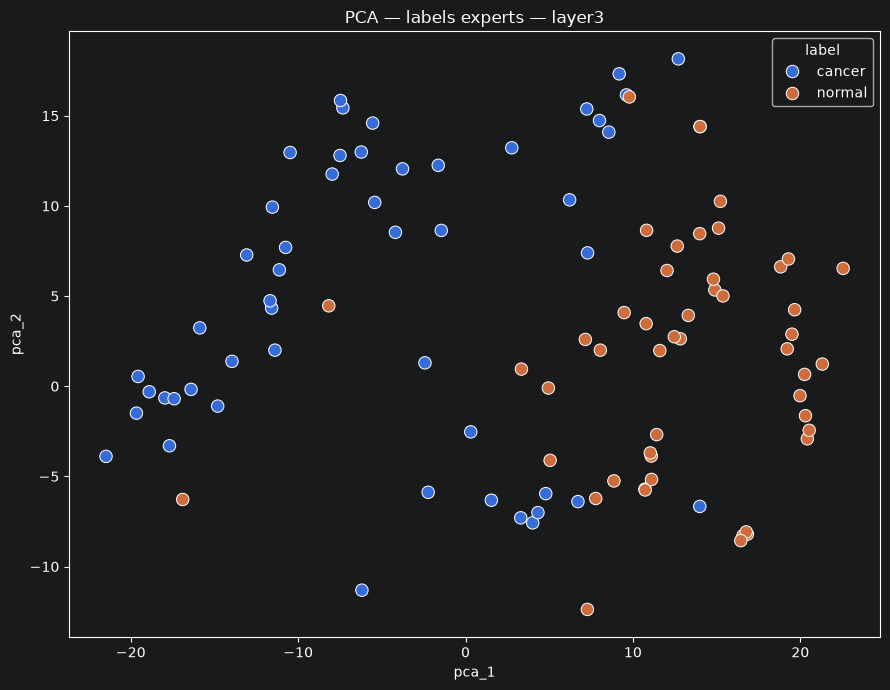

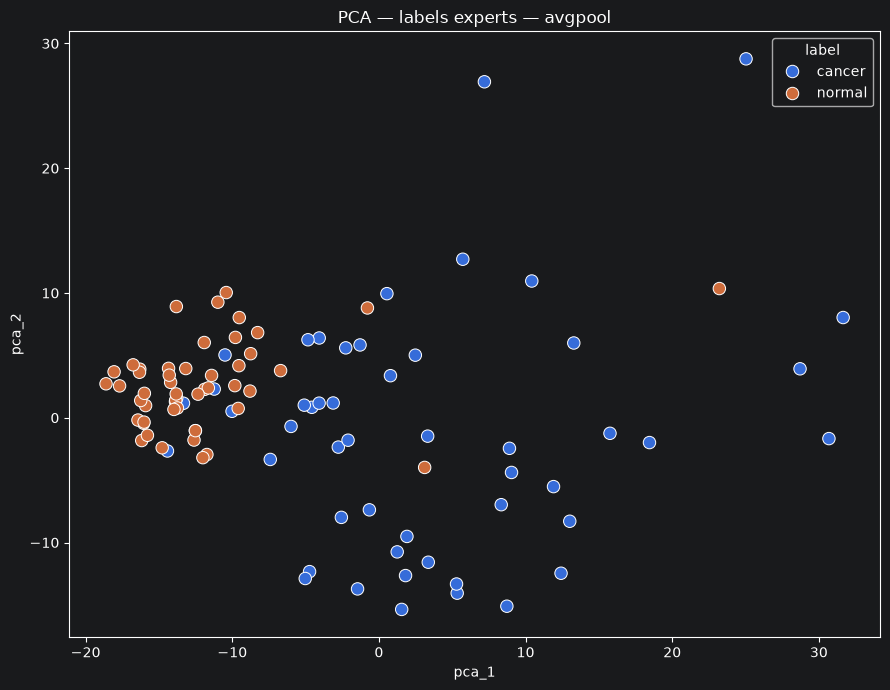

In [54]:
for nom, dataframe in projections.items():
    donnees_fortes = dataframe[
        dataframe["label"].notna()
    ]

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=donnees_fortes,
        x="pca_1",
        y="pca_2",
        hue="label",
        s=80,
    )

    plt.title(
        f"PCA — labels experts — {nom}"
    )

    plt.tight_layout()
    plt.show()

Puis en t-SNE :

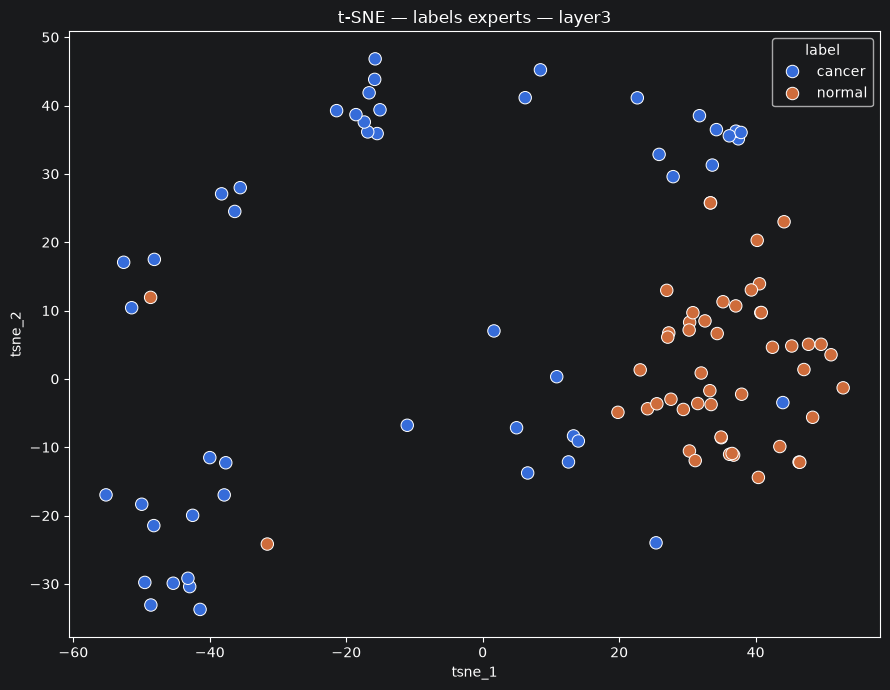

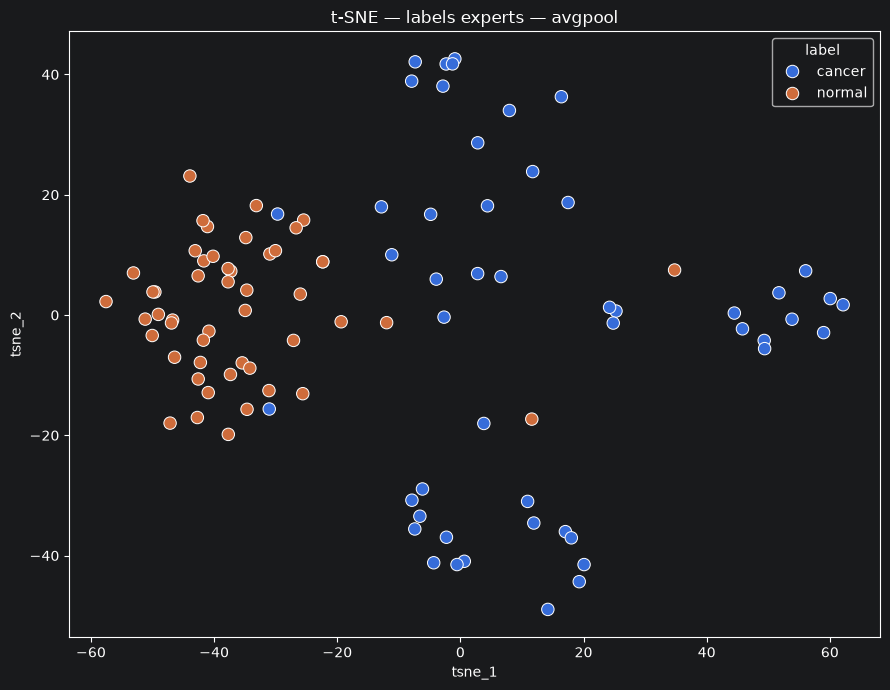

In [55]:
for nom, dataframe in projections.items():
    donnees_fortes = dataframe[
        dataframe["label"].notna()
    ]

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=donnees_fortes,
        x="tsne_1",
        y="tsne_2",
        hue="label",
        s=80,
    )

    plt.title(
        f"t-SNE — labels experts — {nom}"
    )

    plt.tight_layout()
    plt.show()

Ces graphes ne servent pas à entraîner un modèle : ils permettent seulement d’observer si les deux classes semblent naturellement séparables.

10. Fonction d’évaluation des clusters

L’ARI compare deux partitions sans exiger que les numéros de clusters correspondent aux numéros de classes. Une permutation comme cluster 0 = cancer et cluster 1 = normal donne donc le même résultat. Un ARI de 1 correspond à une concordance parfaite, une valeur proche de 0 à un regroupement proche du hasard et une valeur négative à une forte discordance.

Le score de silhouette varie de -1 à 1 : une valeur élevée indique des groupes mieux séparés, une valeur proche de zéro des groupes superposés et une valeur négative des affectations potentiellement incohérentes.

Cellule Code

In [56]:
def evaluer_clustering(
    representation: str,
    algorithme: str,
    X: np.ndarray,
    labels_clusters: np.ndarray,
    parametres: dict,
) -> dict:
    """
    Évalue un clustering avec des métriques internes et l'ARI.
    """

    labels_clusters = np.asarray(
        labels_clusters
    )

    masque_hors_bruit = (
        labels_clusters != -1
    )

    clusters_hors_bruit = np.unique(
        labels_clusters[
            masque_hors_bruit
        ]
    )

    nombre_clusters = len(
        clusters_hors_bruit
    )

    resultat = {
        "representation": representation,
        "algorithme": algorithme,
        "parametres": json.dumps(
            parametres,
            ensure_ascii=False,
        ),
        "nombre_clusters": nombre_clusters,
        "nombre_bruit": int(
            np.sum(~masque_hors_bruit)
        ),
        "pourcentage_bruit": float(
            np.mean(~masque_hors_bruit) * 100
        ),
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "ari_labels_forts": np.nan,
        "couverture_labels_forts": np.nan,
    }

    if (
        nombre_clusters >= 2
        and masque_hors_bruit.sum()
        > nombre_clusters
    ):
        X_evaluation = X[
            masque_hors_bruit
        ]

        labels_evaluation = labels_clusters[
            masque_hors_bruit
        ]

        resultat["silhouette"] = float(
            silhouette_score(
                X_evaluation,
                labels_evaluation,
            )
        )

        resultat["davies_bouldin"] = float(
            davies_bouldin_score(
                X_evaluation,
                labels_evaluation,
            )
        )

        resultat[
            "calinski_harabasz"
        ] = float(
            calinski_harabasz_score(
                X_evaluation,
                labels_evaluation,
            )
        )

    clusters_forts = labels_clusters[
        strong_mask
    ]

    resultat["ari_labels_forts"] = float(
        adjusted_rand_score(
            y_strong,
            clusters_forts,
        )
    )

    resultat[
        "couverture_labels_forts"
    ] = float(
        np.mean(clusters_forts != -1)
        * 100
    )

    return resultat

11. K-Means et clustering hiérarchique

K-Means sera explicitement configuré avec deux clusters. Le clustering agglomératif fusionne progressivement les groupes ; nous l’utilisons également avec deux clusters et le critère de Ward.

Cellule Code

In [57]:
resultats = []
predictions = {}
modeles = {}

for nom, espace in espaces.items():
    X = espace["X_clustering"]

    kmeans = KMeans(
        n_clusters=2,
        n_init=50,
        random_state=RANDOM_STATE,
    )

    labels_kmeans = kmeans.fit_predict(
        X
    )

    predictions[
        (nom, "KMeans")
    ] = labels_kmeans

    modeles[
        (nom, "KMeans")
    ] = kmeans

    resultats.append(
        evaluer_clustering(
            representation=nom,
            algorithme="KMeans",
            X=X,
            labels_clusters=labels_kmeans,
            parametres={
                "n_clusters": 2,
                "n_init": 50,
            },
        )
    )

    agglomeratif = AgglomerativeClustering(
        n_clusters=2,
        linkage="ward",
    )

    labels_agglomeratif = (
        agglomeratif.fit_predict(X)
    )

    predictions[
        (nom, "Agglomerative")
    ] = labels_agglomeratif

    modeles[
        (nom, "Agglomerative")
    ] = agglomeratif

    resultats.append(
        evaluer_clustering(
            representation=nom,
            algorithme="Agglomerative",
            X=X,
            labels_clusters=(
                labels_agglomeratif
            ),
            parametres={
                "n_clusters": 2,
                "linkage": "ward",
            },
        )
    )

12. Recherche DBSCAN

Contrairement à K-Means, DBSCAN ne permet pas d’imposer directement deux clusters. Il détecte les zones denses et peut également classer certains points comme bruit avec le label -1. Nous rechercherons donc une configuration donnant idéalement deux clusters sans utiliser les labels experts pour sélectionner eps.

Cellule Code

In [58]:
def rechercher_dbscan(
    representation: str,
    X: np.ndarray,
) -> tuple[pd.DataFrame, dict]:
    """
    Teste plusieurs paramètres DBSCAN à partir des distances
    de voisinage.

    Une clé textuelle est utilisée pour eps afin d'éviter
    les problèmes de précision des nombres flottants.
    """

    lignes = []
    candidats = {}

    min_samples_values = [
        5,
        10,
        15,
        20,
    ]

    quantiles_eps = [
        0.70,
        0.75,
        0.80,
        0.85,
        0.90,
        0.92,
        0.94,
        0.96,
        0.98,
    ]

    for min_samples in min_samples_values:
        voisins = NearestNeighbors(
            n_neighbors=min_samples,
            n_jobs=-1,
        )

        voisins.fit(X)

        distances, _ = voisins.kneighbors(X)
        distances_k = distances[:, -1]

        eps_values = np.unique(
            np.quantile(
                distances_k,
                quantiles_eps,
            )
        )

        for eps in eps_values:
            eps_value = float(eps)

            # Clé stable utilisée dans le dictionnaire.
            eps_key = f"{eps_value:.6f}"

            modele = DBSCAN(
                eps=eps_value,
                min_samples=min_samples,
                n_jobs=-1,
            )

            labels = modele.fit_predict(X)

            cle = (
                representation,
                eps_key,
                int(min_samples),
            )

            candidats[cle] = {
                "modele": modele,
                "labels": labels,
            }

            lignes.append(
                evaluer_clustering(
                    representation=representation,
                    algorithme="DBSCAN",
                    X=X,
                    labels_clusters=labels,
                    parametres={
                        "eps": float(eps_key),
                        "min_samples": int(min_samples),
                    },
                )
            )

    return pd.DataFrame(lignes), candidats

In [59]:
resultats_dbscan = []
candidats_dbscan = {}

for nom, espace in espaces.items():
    dataframe_dbscan, candidats = (
        rechercher_dbscan(
            representation=nom,
            X=espace["X_clustering"],
        )
    )

    resultats_dbscan.append(
        dataframe_dbscan
    )

    candidats_dbscan.update(
        candidats
    )

df_dbscan = pd.concat(
    resultats_dbscan,
    ignore_index=True,
)

display(
    df_dbscan.sort_values(
        [
            "nombre_clusters",
            "silhouette",
        ],
        ascending=[
            True,
            False,
        ],
    ).head(20)
)

,representation,algorithme,parametres,nombre_clusters,nombre_bruit,pourcentage_bruit,silhouette,davies_bouldin,calinski_harabasz,ari_labels_forts,couverture_labels_forts
6,layer3,DBSCAN,"{""eps"": 34.842686, ""min_samples"": 5}",1,60,3.984064,NaN,NaN,NaN,-0.000777,97.0
7,layer3,DBSCAN,"{""eps"": 36.028802, ""min_samples"": 5}",1,45,2.988048,NaN,NaN,NaN,-0.000793,98.0
8,layer3,DBSCAN,"{""eps"": 39.614523, ""min_samples"": 5}",1,18,1.195219,NaN,NaN,NaN,0.000000,100.0
9,layer3,DBSCAN,"{""eps"": 28.880721, ""min_samples"": 10}",1,271,17.994688,NaN,NaN,NaN,0.108500,73.0
10,layer3,DBSCAN,"{""eps"": 29.797612, ""min_samples"": 10}",1,223,14.807437,NaN,NaN,NaN,0.095736,76.0
11,layer3,DBSCAN,"{""eps"": 31.045404, ""min_samples"": 10}",1,174,11.553785,NaN,NaN,NaN,0.051468,80.0
12,layer3,DBSCAN,"{""eps"": 32.720764, ""min_samples"": 10}",1,123,8.167331,NaN,NaN,NaN,-0.002044,90.0
13,layer3,DBSCAN,"{""eps"": 34.797199, ""min_samples"": 10}",1,79,5.245684,NaN,NaN,NaN,0.000049,96.0
14,layer3,DBSCAN,"{""eps"": 35.653309, ""min_samples"": 10}",1,59,3.917663,NaN,NaN,NaN,-0.000793,98.0
15,layer3,DBSCAN,"{""eps"": 36.77704, ""min_samples"": 10}",1,41,2.722444,NaN,NaN,NaN,0.000000,99.0


13. Sélection interne du meilleur DBSCAN

Nous privilégions :

exactement deux clusters ;
une silhouette élevée ;
un faible pourcentage de bruit.

L’ARI n’intervient pas dans cette sélection.

In [60]:
for nom in espaces:
    candidats_deux_clusters = (
        df_dbscan[
            (df_dbscan["representation"] == nom)
            & (df_dbscan["nombre_clusters"] == 2)
            & (df_dbscan["silhouette"].notna())
        ]
        .sort_values(
            [
                "silhouette",
                "pourcentage_bruit",
            ],
            ascending=[
                False,
                True,
            ],
        )
    )

    if candidats_deux_clusters.empty:
        print(
            f"Aucun DBSCAN à deux clusters pour {nom}."
        )
        continue

    meilleur = candidats_deux_clusters.iloc[0]

    parametres = json.loads(
        meilleur["parametres"]
    )

    # Même représentation textuelle que lors de la création.
    eps_key = f"{float(parametres['eps']):.6f}"

    cle = (
        nom,
        eps_key,
        int(parametres["min_samples"]),
    )

    candidat = candidats_dbscan[cle]

    predictions[
        (nom, "DBSCAN")
    ] = candidat["labels"]

    modeles[
        (nom, "DBSCAN")
    ] = candidat["modele"]

    resultats.append(
        meilleur.to_dict()
    )

    print(
        f"DBSCAN sélectionné pour {nom} : "
        f"eps={parametres['eps']}, "
        f"min_samples={parametres['min_samples']}, "
        f"silhouette={meilleur['silhouette']:.4f}, "
        f"bruit={meilleur['pourcentage_bruit']:.2f} %"
    )

DBSCAN sélectionné pour layer3 : eps=33.743122, min_samples=5, silhouette=0.1229, bruit=5.58 %
Aucun DBSCAN à deux clusters pour avgpool.


14. Comparer les résultats

In [61]:
df_resultats = pd.DataFrame(
    resultats
)

df_resultats = df_resultats.sort_values(
    [
        "ari_labels_forts",
        "silhouette",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

display(
    df_resultats[
        [
            "representation",
            "algorithme",
            "nombre_clusters",
            "pourcentage_bruit",
            "silhouette",
            "davies_bouldin",
            "calinski_harabasz",
            "ari_labels_forts",
            "couverture_labels_forts",
            "parametres",
        ]
    ]
)

,representation,algorithme,nombre_clusters,pourcentage_bruit,silhouette,davies_bouldin,calinski_harabasz,ari_labels_forts,couverture_labels_forts,parametres
0,avgpool,Agglomerative,2,0.000000,0.049917,3.883985,81.748675,0.457233,100.0,"{""n_clusters"": 2, ""linkage"": ""ward""}"
1,layer3,KMeans,2,0.000000,0.113975,2.738350,193.027774,0.430234,100.0,"{""n_clusters"": 2, ""n_init"": 50}"
2,layer3,Agglomerative,2,0.000000,0.102597,2.907993,172.127825,0.430234,100.0,"{""n_clusters"": 2, ""linkage"": ""ward""}"
3,avgpool,KMeans,2,0.000000,0.142500,3.861937,92.691672,0.123523,100.0,"{""n_clusters"": 2, ""n_init"": 50}"
4,layer3,DBSCAN,2,5.577689,0.122918,1.671584,10.296357,-0.002284,94.0,"{""eps"": 33.743122, ""min_samples"": 5}"


15. Visualiser les clusters en PCA

In [62]:
def afficher_clusters_pca(
    representation: str,
    algorithme: str,
) -> None:
    """
    Affiche en PCA 2D les clusters d'un algorithme.
    """

    projection = projections[
        representation
    ].copy()

    projection["cluster"] = (
        predictions[
            (representation, algorithme)
        ]
        .astype(str)
    )

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=projection,
        x="pca_1",
        y="pca_2",
        hue="cluster",
        s=35,
        alpha=0.75,
    )

    plt.title(
        f"{algorithme} — {representation} — PCA"
    )

    plt.tight_layout()
    plt.show()

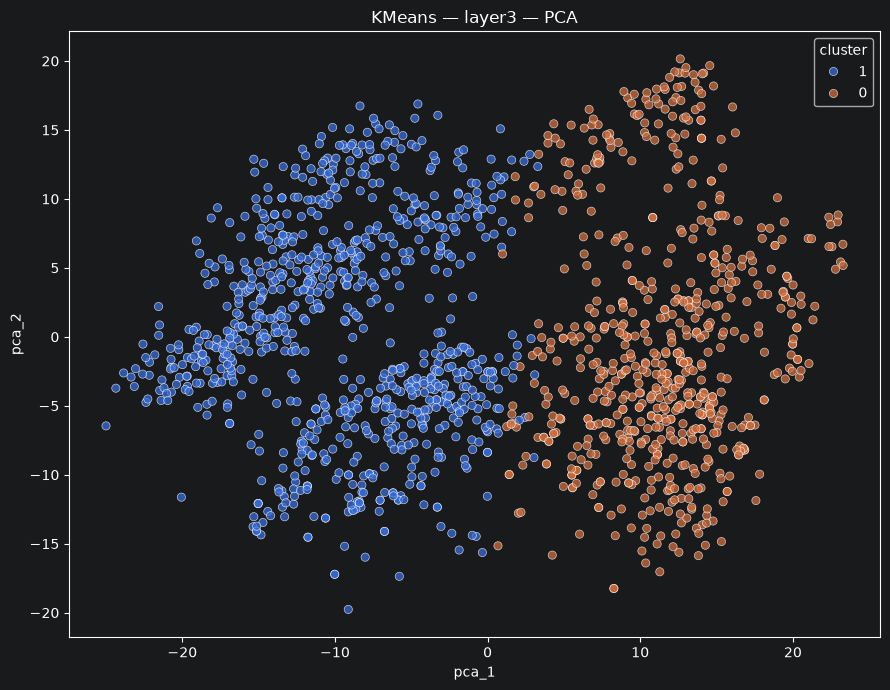

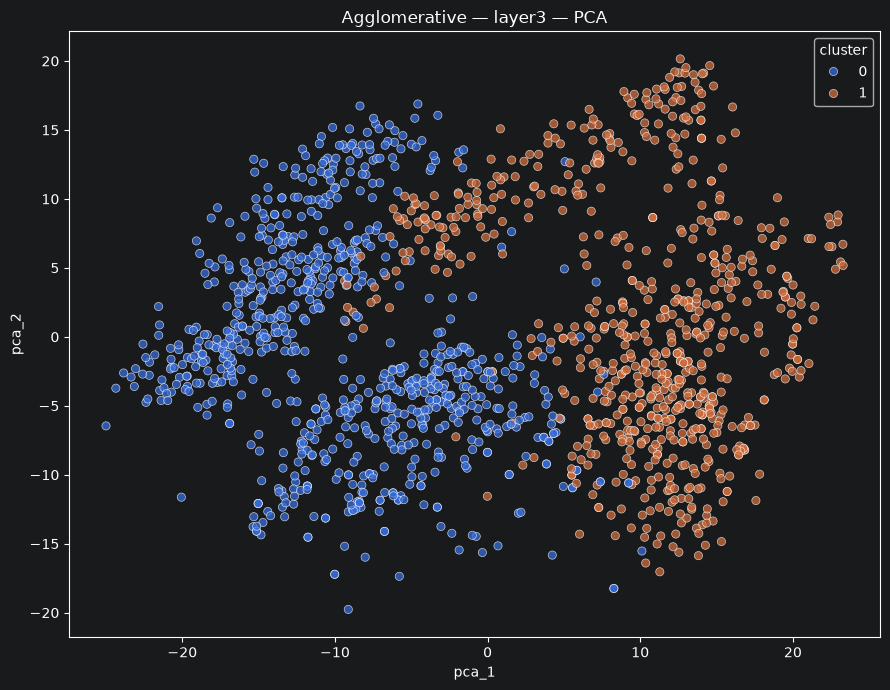

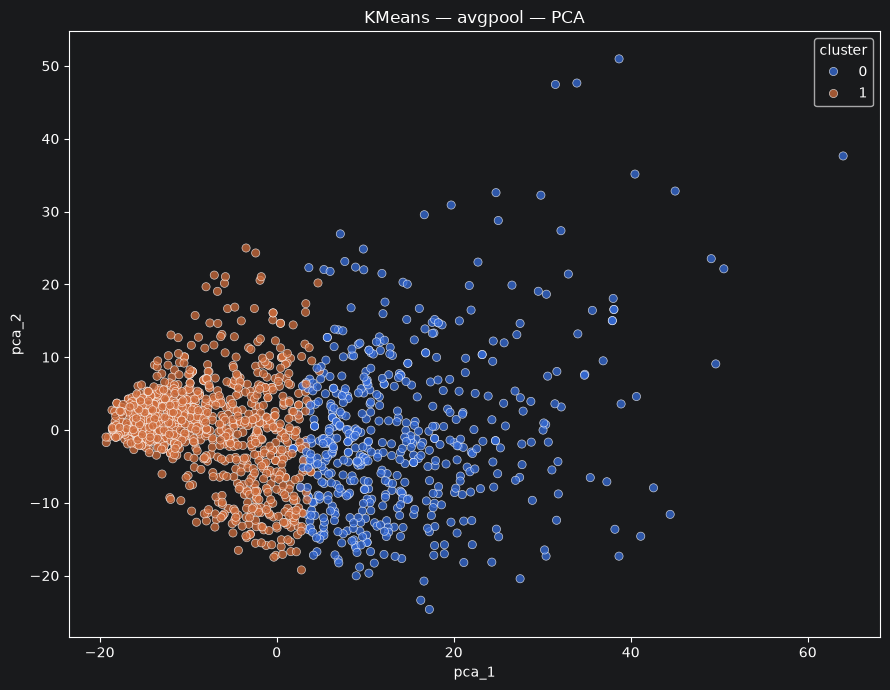

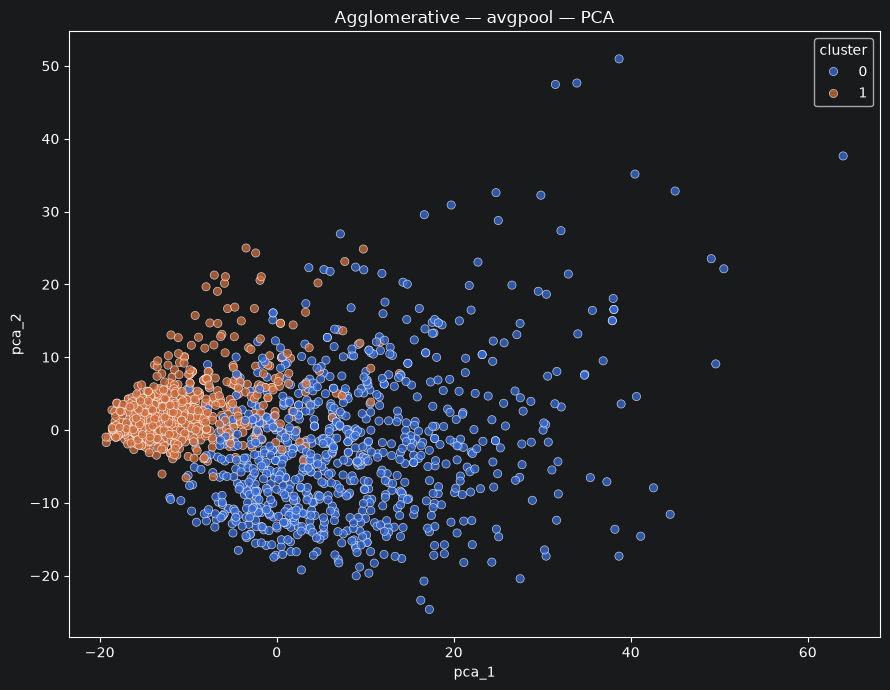

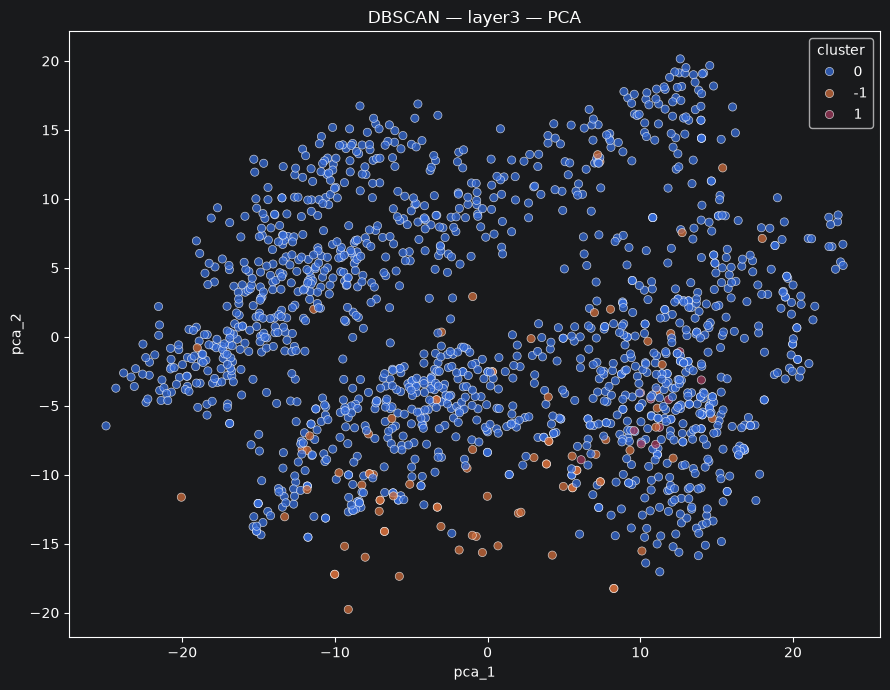

In [63]:
for cle in predictions:
    representation, algorithme = cle

    afficher_clusters_pca(
        representation,
        algorithme,
    )